<a href="https://colab.research.google.com/github/juliusnugroho05/Big-Data-Air-Quality-Project/blob/main/Big_Data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SETUP PYSPARK

In [ ]:
!pip install pyspark

In [ ]:
!pip install imbalanced-learn

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BrooklynAirQuality") \
    .master("local[*]") \
    .getOrCreate()

print("Spark is running!")

Spark is running!


# LOAD DATASET

In [ ]:
measurements = spark.read.csv(
    "measurements.csv",
    header=True,
    inferSchema=True
)

stations = spark.read.option("header", True).option("multiLine", True).csv("stations.csv")

In [ ]:
stations.show()

+----------+----------------+----------+-----------+--------------------+------+
|station_id|    station_name|  latitude|  longitude|         sensor_type|source|
+----------+----------------+----------+-----------+--------------------+------+
|   3041962|\tNear Bay 50 St|40.5887458|-73.9838231|\t\nAir sensor st...|OpenAQ|
|       648|  Bklyn - PS 314| 40.641819| -74.018707|\t\nReference gra...|OpenAQ|
+----------+----------------+----------+-----------+--------------------+------+



In [ ]:
from pyspark.sql.functions import col, trim, regexp_replace

stations = stations.withColumn(
    "station_name",
    trim(regexp_replace(col("station_name"), r"[\t\n\r]", " "))
)

stations = stations.withColumn(
    "sensor_type",
    trim(regexp_replace(col("sensor_type"), r"[\t\n\r]", " "))
)

In [ ]:
stations.show(truncate=False)

+----------+--------------+----------+-----------+--------------------------+------+
|station_id|station_name  |latitude  |longitude  |sensor_type               |source|
+----------+--------------+----------+-----------+--------------------------+------+
|3041962   |Near Bay 50 St|40.5887458|-73.9838231|Air sensor stationary     |OpenAQ|
|648       |Bklyn - PS 314|40.641819 |-74.018707 |Reference grade stationary|OpenAQ|
+----------+--------------+----------+-----------+--------------------------+------+



In [ ]:
print("Measurements Columns:")
print(measurements.columns)

print("Stations Columns:")
print(stations.columns)

Measurements Columns:
['location_id', 'location_name', 'parameter', 'value', 'unit', 'datetimeUtc', 'datetimeLocal', 'timezone', 'latitude', 'longitude', 'country_iso', 'isMobile', 'isMonitor', 'owner_name', 'provider']
Stations Columns:
['station_id', 'station_name', 'latitude', 'longitude', 'sensor_type', 'source']


# DATA EXPLORATION

In [ ]:
measurements.show(5)

measurements.printSchema()

measurements.describe().show()

+-----------+--------------+---------+-----------+-----+-------------------+-------------------+----------------+----------+-----------+-----------+--------+---------+----------+-----------+
|location_id| location_name|parameter|      value| unit|        datetimeUtc|      datetimeLocal|        timezone|  latitude|  longitude|country_iso|isMobile|isMonitor|owner_name|   provider|
+-----------+--------------+---------+-----------+-----+-------------------+-------------------+----------------+----------+-----------+-----------+--------+---------+----------+-----------+
|    3041962|Near Bay 50 St|     pm25|     41.125|µg/m³|2025-08-01 01:00:00|2025-08-01 01:00:00|America/New_York|40.5887458|-73.9838231|       NULL|    NULL|     NULL| Sebastian|AirGradient|
|    3041962|Near Bay 50 St|     pm25|46.66666667|µg/m³|2025-08-01 02:00:00|2025-08-01 02:00:00|America/New_York|40.5887458|-73.9838231|       NULL|    NULL|     NULL| Sebastian|AirGradient|
|    3041962|Near Bay 50 St|     pm25|      4

In [ ]:
stations.show(truncate=False)

stations.printSchema()

stations.describe().show()

+----------+--------------+----------+-----------+--------------------------+------+
|station_id|station_name  |latitude  |longitude  |sensor_type               |source|
+----------+--------------+----------+-----------+--------------------------+------+
|3041962   |Near Bay 50 St|40.5887458|-73.9838231|Air sensor stationary     |OpenAQ|
|648       |Bklyn - PS 314|40.641819 |-74.018707 |Reference grade stationary|OpenAQ|
+----------+--------------+----------+-----------+--------------------------+------+

root
 |-- station_id: string (nullable = true)
 |-- station_name: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- sensor_type: string (nullable = true)
 |-- source: string (nullable = true)

+-------+------------------+--------------+-------------------+--------------------+--------------------+------+
|summary|        station_id|  station_name|           latitude|           longitude|         sensor_type|source|
+-------+

As we can see the station id and location id, station name and location name, latitude longitude are same. So we dont use the stations dataset.

# DATA CLEANING

remove duplicate

In [ ]:
measurements = measurements.dropDuplicates()

In [ ]:
total_rows = measurements.count()
unique_rows = measurements.distinct().count()

duplicate = total_rows - unique_rows
print(duplicate)

0


# filter invalid PM2.5 values

Since PM2.5 minimum quality value is zero, then we need to filter the data to make sure the minimum value is 0

In [ ]:
from pyspark.sql.functions import col

measurements = measurements.filter(
    col("value") >= 0
)

remove rows with important NULL values

In [ ]:
from pyspark.sql.functions import  sum

measurements.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in measurements.columns
]).show()

+-----------+-------------+---------+-----+----+-----------+-------------+--------+--------+---------+-----------+--------+---------+----------+--------+
|location_id|location_name|parameter|value|unit|datetimeUtc|datetimeLocal|timezone|latitude|longitude|country_iso|isMobile|isMonitor|owner_name|provider|
+-----------+-------------+---------+-----+----+-----------+-------------+--------+--------+---------+-----------+--------+---------+----------+--------+
|          0|            0|        0|    0|   0|          0|            0|       0|       0|        0|       1391|    1391|     1391|         0|       0|
+-----------+-------------+---------+-----+----+-----------+-------------+--------+--------+---------+-----------+--------+---------+----------+--------+



In [ ]:
measurements = measurements.fillna({
    "country_iso": "Unknown",
    "isMobile": "Unknown",
    "isMonitor": "Unknown"
})

In [ ]:
measurements.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in measurements.columns
]).show()

+-----------+-------------+---------+-----+----+-----------+-------------+--------+--------+---------+-----------+--------+---------+----------+--------+
|location_id|location_name|parameter|value|unit|datetimeUtc|datetimeLocal|timezone|latitude|longitude|country_iso|isMobile|isMonitor|owner_name|provider|
+-----------+-------------+---------+-----+----+-----------+-------------+--------+--------+---------+-----------+--------+---------+----------+--------+
|          0|            0|        0|    0|   0|          0|            0|       0|       0|        0|          0|       0|        0|         0|       0|
+-----------+-------------+---------+-----+----+-----------+-------------+--------+--------+---------+-----------+--------+---------+----------+--------+



# DATA TRANSFORMATION

Convert timestamp into useful columns.

In [ ]:
from pyspark.sql.functions import (
    year,
    month,
    dayofmonth,
    hour,
    to_timestamp
)

# convert string to timestamp
measurements = measurements.withColumn(
    "datetimeUtc",
    to_timestamp("datetimeUtc")
)

# extract year
measurements = measurements.withColumn(
    "year",
    year("datetimeUtc")
)

# extract month
measurements = measurements.withColumn(
    "month",
    month("datetimeUtc")
)

# extract day
measurements = measurements.withColumn(
    "day",
    dayofmonth("datetimeUtc")
)

# extract hour
measurements = measurements.withColumn(
    "hour",
    hour("datetimeUtc")
)

In [ ]:
measurements.select(
    "datetimeUtc",
    "year",
    "month",
    "day",
    "hour"
).show(5)

+-------------------+----+-----+---+----+
|        datetimeUtc|year|month|day|hour|
+-------------------+----+-----+---+----+
|2025-08-06 16:00:00|2025|    8|  6|  16|
|2025-08-09 02:00:00|2025|    8|  9|   2|
|2025-08-05 06:00:00|2025|    8|  5|   6|
|2025-08-17 08:00:00|2025|    8| 17|   8|
|2025-08-29 23:00:00|2025|    8| 29|  23|
+-------------------+----+-----+---+----+
only showing top 5 rows


In [ ]:
measurements.show(5)

+-----------+--------------+---------+-----------+-----+-------------------+-------------------+----------------+----------+-----------+-----------+--------+---------+--------------------+-----------+----+-----+---+----+
|location_id| location_name|parameter|      value| unit|        datetimeUtc|      datetimeLocal|        timezone|  latitude|  longitude|country_iso|isMobile|isMonitor|          owner_name|   provider|year|month|day|hour|
+-----------+--------------+---------+-----------+-----+-------------------+-------------------+----------------+----------+-----------+-----------+--------+---------+--------------------+-----------+----+-----+---+----+
|    3041962|Near Bay 50 St|     pm25|46.08333333|µg/m³|2025-08-06 16:00:00|2025-08-06 16:00:00|America/New_York|40.5887458|-73.9838231|    Unknown| Unknown|  Unknown|           Sebastian|AirGradient|2025|    8|  6|  16|
|    3041962|Near Bay 50 St|     pm25|8.333333333|µg/m³|2025-08-09 02:00:00|2025-08-09 02:00:00|America/New_York|40.

In [ ]:
data = measurements

# AGGREGATION

Average PM2.5 by Provider

In [ ]:
from pyspark.sql.functions import avg

avg_pm25 = data.groupBy("provider").agg(avg("value").alias("avg_pm25"))

avg_pm25.show()

+-----------+------------------+
|   provider|          avg_pm25|
+-----------+------------------+
|AirGradient|15.159764983448262|
|     AirNow| 8.937697841726619|
+-----------+------------------+



Daily Average PM2.5

In [ ]:
from pyspark.sql.functions import avg

daily_pm25 = data.groupBy("day").agg(avg("value").alias("daily_avg_pm25")).orderBy("day")

daily_pm25.show(31)

+---+------------------+
|day|    daily_avg_pm25|
+---+------------------+
|  1| 14.75777777806667|
|  2|   20.731076389375|
|  3|16.636805554791664|
|  4|21.033680555416662|
|  5| 34.76111111041666|
|  6|26.724826388666667|
|  7|14.086111111145827|
|  8| 5.422222222187501|
|  9| 8.511805555458334|
| 10| 9.490625000083332|
| 11| 14.99809027770833|
| 12|12.768529040208335|
| 13|10.572395833541664|
| 14|   14.173958333125|
| 15|21.788541666666664|
| 16| 19.65371272229167|
| 17|20.422930946666668|
| 18|   9.0148411195625|
| 19|3.7394014550416674|
| 20| 4.158043981479166|
| 21| 3.009027777791666|
| 22| 6.211284722208333|
| 23| 8.269270833312499|
| 24| 4.995486111083334|
| 25| 5.461168980958333|
| 26| 3.351215277708333|
| 27|2.8567708333125004|
| 28| 5.589930555645835|
| 29|6.7460542927708325|
| 30| 5.104166666499999|
+---+------------------+



Monthly Average PM2.5

In [ ]:
monthly_pm25 = data.groupBy("month").agg(avg("value").alias("monthly_avg_pm25"))

monthly_pm25.show()

+-----+------------------+
|month|  monthly_avg_pm25|
+-----+------------------+
|    8|12.050967957210634|
+-----+------------------+



Average PM2.5 by Hour

In [ ]:
hourly_pm25 = data.groupBy("hour").agg(avg("value").alias("hourly_avg_pm25"))

hourly_pm25.show()

+----+------------------+
|hour|   hourly_avg_pm25|
+----+------------------+
|  12|12.762976750206898|
|  22|11.644849355586206|
|   1|12.014838035568966|
|  13|12.927248469862063|
|  16|13.562787356137926|
|   6|10.986004440862073|
|   3| 12.00770202005172|
|  20|11.749425287655171|
|   5|11.505777603620691|
|  19|12.050562894603443|
|  15|13.311977534206898|
|   9|11.374675324241377|
|  17|13.318208399561405|
|   4|11.793486590137928|
|   8|10.941758098172413|
|  23|  10.9549634272069|
|   7| 10.75466954022414|
|  10|12.042552682172417|
|  21|12.005925635465516|
|  11|12.381117206706902|
+----+------------------+
only showing top 20 rows


# FEATURE ENGINEERING

In [ ]:
from pyspark.sql.functions import when, col

data = data.withColumn(
    "pollution_level",
    when(col("value") <= 15, "Good")
    .when(col("value") <= 40, "Moderate")
    .otherwise("Unhealthy")
)

# DESCRIPTIVE ANALYTICS

Pollution Category Distribution

In [ ]:
data.groupBy("pollution_level").count().show()

+---------------+-----+
|pollution_level|count|
+---------------+-----+
|      Unhealthy|   27|
|           Good| 1024|
|       Moderate|  340|
+---------------+-----+



# Modeling (Classification) & SMOTE



In [ ]:
from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="pollution_level",
    outputCol="label"
)

data = label_indexer.fit(data).transform(data)

In [ ]:
data.select(
    "pollution_level",
    "label"
).show(10)

+---------------+-----+
|pollution_level|label|
+---------------+-----+
|      Unhealthy|  2.0|
|           Good|  0.0|
|       Moderate|  1.0|
|           Good|  0.0|
|           Good|  0.0|
|       Moderate|  1.0|
|           Good|  0.0|
|           Good|  0.0|
|           Good|  0.0|
|           Good|  0.0|
+---------------+-----+
only showing top 10 rows


In [ ]:
feature_cols = [
    "latitude",
    "longitude",
    "month",
    "day",
    "hour"
]

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

data = assembler.transform(data)

In [ ]:
data.select(
    "features",
    "label"
).show(5, truncate=False)

+-------------------------------------+-----+
|features                             |label|
+-------------------------------------+-----+
|[40.5887458,-73.9838231,8.0,6.0,16.0]|2.0  |
|[40.5887458,-73.9838231,8.0,9.0,2.0] |0.0  |
|[40.641819,-74.018707,8.0,5.0,6.0]   |1.0  |
|[40.641819,-74.018707,8.0,17.0,8.0]  |0.0  |
|[40.641819,-74.018707,8.0,29.0,23.0] |0.0  |
+-------------------------------------+-----+
only showing top 5 rows


In [ ]:
train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [ ]:
print("Train:", train_data.count())
print("Test :", test_data.count())

Train: 1151
Test : 240


In [ ]:
train_data.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|  852|
|  1.0|  278|
|  2.0|   21|
+-----+-----+



In [ ]:
train_pd = train_data.select(
    "latitude",
    "longitude",
    "month",
    "day",
    "hour",
    "label"
).toPandas()

In [ ]:
train_pd.head()

,latitude,longitude,month,day,hour,label
0,40.641819,-74.018707,8,21,9,0.0
1,40.641819,-74.018707,8,21,6,0.0
2,40.641819,-74.018707,8,21,8,0.0
3,40.641819,-74.018707,8,20,22,0.0
4,40.641819,-74.018707,8,20,23,0.0


In [ ]:
train_pd["label"].value_counts()

,count
label,
0.0,852
1.0,278
2.0,21


In [ ]:
from imblearn.over_sampling import SMOTE

X = train_pd.drop("label", axis=1)
y = train_pd["label"]

smote = SMOTE(
    sampling_strategy={
        1.0: 600,
        2.0: 300
    },
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [ ]:
from collections import Counter

print(Counter(y_resampled))

Counter({0.0: 852, 1.0: 600, 2.0: 300})


In [ ]:
import pandas as pd

train_resampled_pd = X_resampled.copy()
train_resampled_pd["label"] = y_resampled

In [ ]:
train_resampled_pd.head()

,latitude,longitude,month,day,hour,label
0,40.641819,-74.018707,8,21,9,0.0
1,40.641819,-74.018707,8,21,6,0.0
2,40.641819,-74.018707,8,21,8,0.0
3,40.641819,-74.018707,8,20,22,0.0
4,40.641819,-74.018707,8,20,23,0.0


In [ ]:
train_resampled_pd["label"].value_counts()

,count
label,
0.0,852
1.0,600
2.0,300


as we can see the smothe process is running successfull and we got the new data count to make it more balance

# change back to spark

In [ ]:
train_resampled_spark = spark.createDataFrame(
    train_resampled_pd
)

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

train_resampled_spark = assembler.transform(
    train_resampled_spark
)

In [ ]:
train_resampled_spark.select(
    "features"
).show(5, truncate=False)

+------------------------------------+
|features                            |
+------------------------------------+
|[40.641819,-74.018707,8.0,21.0,9.0] |
|[40.641819,-74.018707,8.0,21.0,6.0] |
|[40.641819,-74.018707,8.0,21.0,8.0] |
|[40.641819,-74.018707,8.0,20.0,22.0]|
|[40.641819,-74.018707,8.0,20.0,23.0]|
+------------------------------------+
only showing top 5 rows


In [ ]:
train_resampled_spark.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|  852|
|  1.0|  600|
|  2.0|  300|
+-----+-----+



In [ ]:
train_resampled_spark.printSchema()

root
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- month: long (nullable = true)
 |-- day: long (nullable = true)
 |-- hour: long (nullable = true)
 |-- label: double (nullable = true)
 |-- features: vector (nullable = true)



In [ ]:
train_resampled_spark.columns

['latitude', 'longitude', 'month', 'day', 'hour', 'label', 'features']

In [ ]:
train_resampled_spark.select(
    "features"
).show(5, truncate=False)

+------------------------------------+
|features                            |
+------------------------------------+
|[40.641819,-74.018707,8.0,21.0,9.0] |
|[40.641819,-74.018707,8.0,21.0,6.0] |
|[40.641819,-74.018707,8.0,21.0,8.0] |
|[40.641819,-74.018707,8.0,20.0,22.0]|
|[40.641819,-74.018707,8.0,20.0,23.0]|
+------------------------------------+
only showing top 5 rows


In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    seed=42
)

In [ ]:
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100, 150])
    .addGrid(rf.maxDepth, [5, 10, 15])
    .build()
)

In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

In [ ]:
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

In [ ]:
model = cv.fit(train_resampled_spark)

In [ ]:
bestModel = model.bestModel

In [ ]:
print("Best NumTrees:", bestModel.getNumTrees)
print("Best MaxDepth:", bestModel.getMaxDepth())

Best NumTrees: 50
Best MaxDepth: 15


In [ ]:
predictions = bestModel.transform(test_data)

In [ ]:
predictions.select(
    "label",
    "prediction"
).show(10)

+-----+----------+
|label|prediction|
+-----+----------+
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
|  0.0|       0.0|
+-----+----------+
only showing top 10 rows


In [ ]:
predictions.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|  170|
|       1.0|   61|
|       2.0|    9|
+----------+-----+



In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9541666666666667


In [ ]:
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1 = f1_evaluator.evaluate(predictions)

print("F1 Score:", f1)

F1 Score: 0.9551328864165833


In [ ]:
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

precision = precision_evaluator.evaluate(predictions)
recall = recall_evaluator.evaluate(predictions)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9578447444551591
Recall: 0.9541666666666667


In [ ]:
for feature, importance in zip(
    feature_cols,
    bestModel.featureImportances
):
    print(feature, ":", importance * 100, "%")

latitude : 9.202943342971317 %
longitude : 9.524309677326432 %
month : 0.0 %
day : 64.89367608557282 %
hour : 16.37907089412943 %


In [ ]:
print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.9541666666666667
F1 Score: 0.9551328864165833


In [ ]:
predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  167|
|  0.0|       1.0|    5|
|  1.0|       0.0|    3|
|  1.0|       1.0|   56|
|  1.0|       2.0|    3|
|  2.0|       2.0|    6|
+-----+----------+-----+



# Visualization EDA

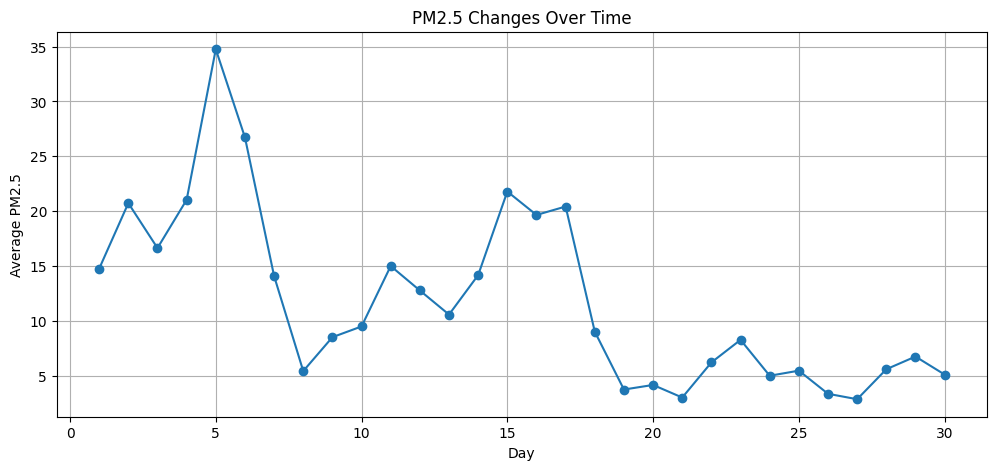

In [ ]:
daily_pd = daily_pm25.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_pd["day"],
    daily_pd["daily_avg_pm25"],
    marker='o'
)

plt.xlabel("Day")
plt.ylabel("Average PM2.5")
plt.title("PM2.5 Changes Over Time")

plt.grid(True)

plt.show()

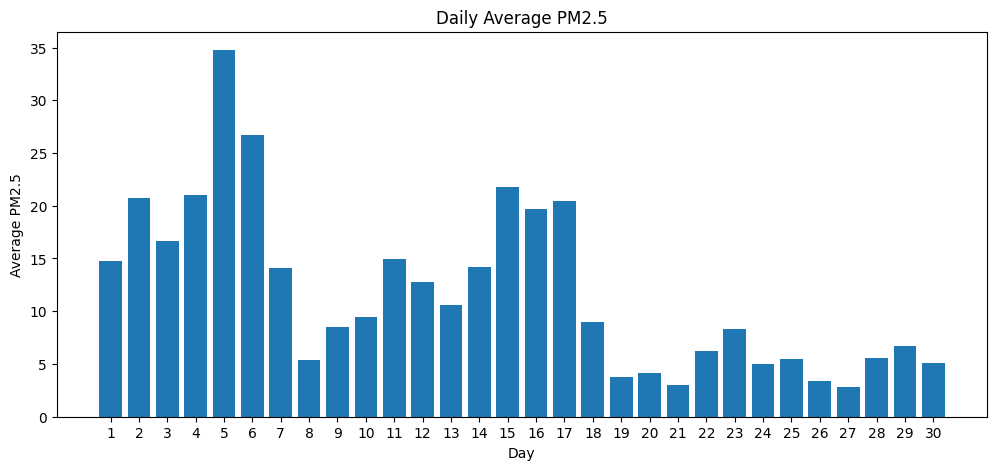

In [ ]:
daily_pd = daily_pm25.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    daily_pd["day"].astype(str),
    daily_pd["daily_avg_pm25"]
)

plt.xlabel("Day")
plt.ylabel("Average PM2.5")
plt.title("Daily Average PM2.5")

plt.show()

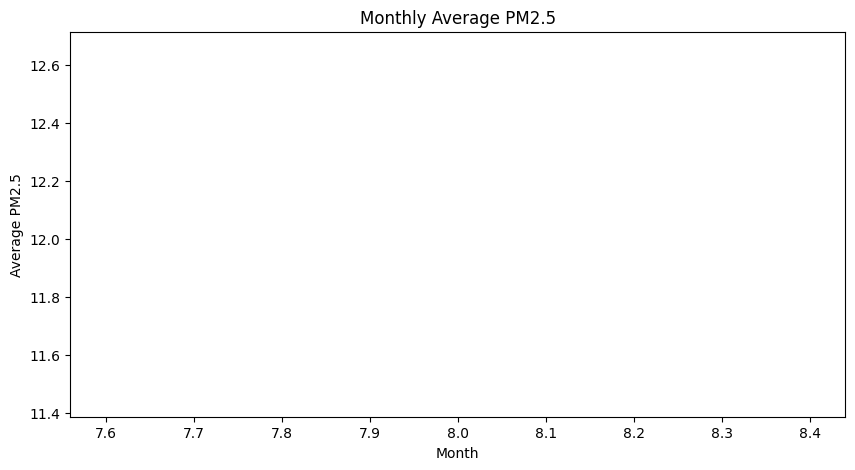

In [ ]:
monthly_pd = monthly_pm25.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(
    monthly_pd["month"],
    monthly_pd["monthly_avg_pm25"]
)

plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly Average PM2.5")
plt.show()

only one x-axis value exists (month = 8),
matplotlib tries to draw a line with only one point,thats why the result looks empty

In [ ]:
monthly_pm25.show()

+-----+------------------+
|month|  monthly_avg_pm25|
+-----+------------------+
|    8|12.050967957210634|
+-----+------------------+



all records are from August only

Since there is only one month, use BAR CHART instead of LINE CHART

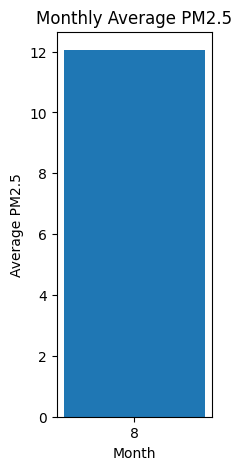

In [ ]:
monthly_pd = monthly_pm25.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(2,5))

plt.bar(
    monthly_pd["month"].astype(str),
    monthly_pd["monthly_avg_pm25"]
)

plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly Average PM2.5")

plt.show()

Pollution Level Distribution

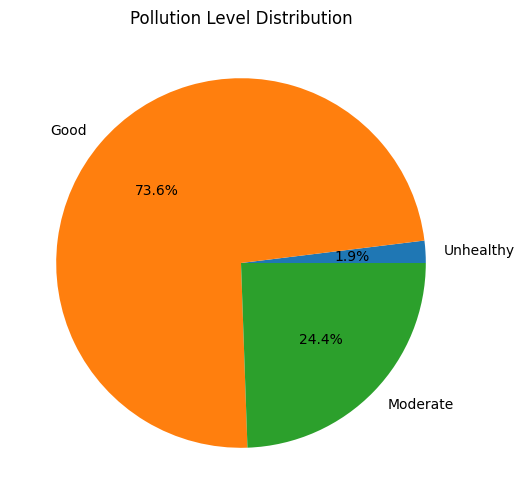

In [ ]:
pollution_pd = data.groupBy(
    "pollution_level"
).count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    pollution_pd["count"],
    labels=pollution_pd["pollution_level"],
    autopct='%1.1f%%'
)

plt.title("Pollution Level Distribution")
plt.show()

Average PM2.5 by Provider

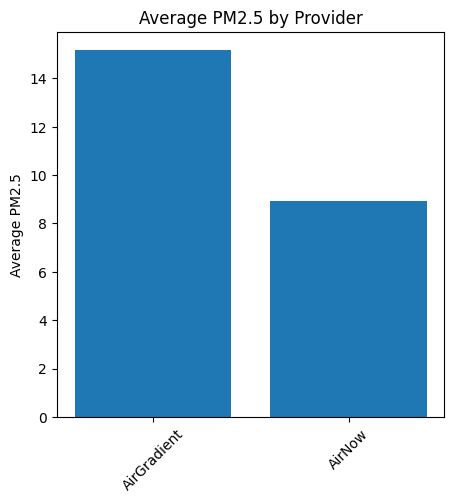

In [ ]:
provider_pd = avg_pm25.toPandas()

plt.figure(figsize=(5,5))
plt.bar(
    provider_pd["provider"],
    provider_pd["avg_pm25"]
)

plt.xticks(rotation=45)
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 by Provider")
plt.show()

# Model Distribution Visualization

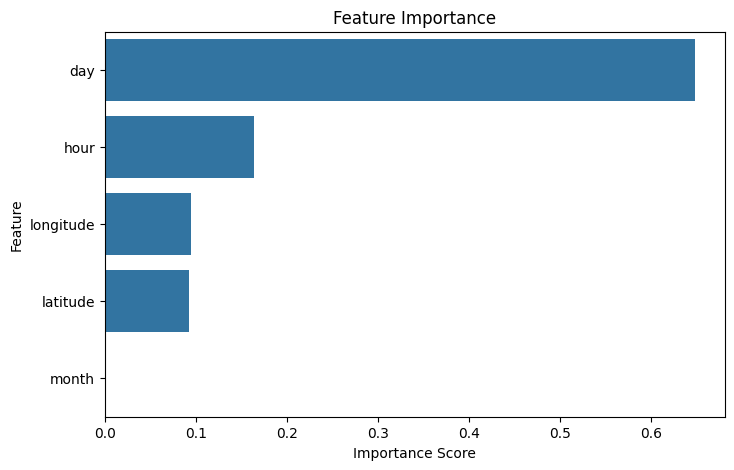

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = bestModel.featureImportances.toArray()

fi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
})

fi_df = fi_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [ ]:
pred_pd = predictions.select(
    "label",
    "prediction"
).toPandas()

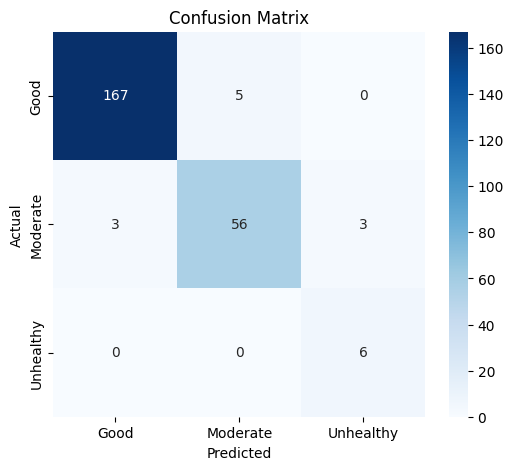

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    pred_pd["label"],
    pred_pd["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good","Moderate","Unhealthy"],
    yticklabels=["Good","Moderate","Unhealthy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()